In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kasun190004b/year-prediction-msd/YearPredictionMSD.txt


## Procesamiento y División de Datos (80/20)
Usamos pandas para revisar el dataset, verificar valores nulos y realizar la imputacion o eliminacion correspondiente
Luego, utilizamos `numpy` para extraer nuestras matrices multilíneales e implementar una partición manual pura. Barajaremos los datos y dividiremos de manera estricta el **80% de los datos para Entrenamiento** (sobre los que se ajustará el modelo) y el **20% residual para Prueba y Testing** evaluando la efectividad predictiva al final.

In [3]:
# Carga del dataset real
url = '/kaggle/input/datasets/kasun190004b/year-prediction-msd/YearPredictionMSD.txt'

# Asumiendo que es un archivo separado por comas
data = pd.read_csv(url, header=None)

# Verificación de datos nulos y limpieza
print("Valores nulos en el dataset antes de limpieza:")
print(data.isnull().sum().sum())
data = data.dropna()

# Extracción a NumPy puro
y_full = data.iloc[:, 0].values
X_full = data.iloc[:, 1:].values
m_full = y_full.size

print("Total general de ejemplos limpios:", m_full)

np.random.seed(42)
indices = np.random.permutation(m_full)

X_shuffled = X_full[indices]
y_shuffled = y_full[indices]

# Calculamos límite del 80% (train) y 20% (Test)
train_limit = int(0.8 * m_full)

# Selección Vectorizada Numpy
X_train = X_shuffled[:train_limit]
y_train = y_shuffled[:train_limit]

X_test = X_shuffled[train_limit:]
y_test = y_shuffled[train_limit:]

m_train = y_train.size
m_test = y_test.size

print("-" * 30)
print(f"Set ENTRENAMIENTO (80%): {m_train} Muestras || X: {X_train.shape}, y: {y_train.shape}")
print(f"Set de PRUEBA (20%):     {m_test} Muestras || X: {X_test.shape}, y: {y_test.shape}")

Valores nulos en el dataset antes de limpieza:
0
Total general de ejemplos limpios: 515345
------------------------------
Set ENTRENAMIENTO (80%): 412276 Muestras || X: (412276, 90), y: (412276,)
Set de PRUEBA (20%):     103069 Muestras || X: (103069, 90), y: (103069,)


## Ingeniería de Características (Creación de Polinomios)

Al tratarse de una **Regresión Polinomial**, nuestra recta original $h_\theta(x) = \theta_0 + \theta_1 x$ no es suficiente. Tenemos que añadir características polinómicas extendiendo la matriz de características originales.

Ejemplo: Convertiremos $X$ a un nuevo dataset $[X, X^2]$ o incluso superior, como $[X, X^2, X^3]$. Todo cálculo y concatenación lo hacemos empleando `numpy`.

In [4]:
# Ampliaremos la matriz de variables al cuadrado para el tensor de ENTRENAMIENTO y PRUEBA
X_poly_train = np.concatenate([X_train, X_train * X_train], axis=1)

# Es fundamental replicar la misma transformación en los datos que validarán el modelo
X_poly_test = np.concatenate([X_test, X_test * X_test], axis=1)

print('Características polinómicas de entrenamiento (dimensión base duplicada):', X_poly_train.shape)
print('Características polinómicas de test adaptadas:', X_poly_test.shape)

Características polinómicas de entrenamiento (dimensión base duplicada): (412276, 180)
Características polinómicas de test adaptadas: (103069, 180)


## Normalización de las Características

En la normalización, uno de los factores más importantes a tomar es que **la Media ($\mu$) y Desviación ($\sigma$) DEBEN ser calculadas EXCLUSIVAMENTE a través de la porción Train.** 

Luego, utilizaremos esas mismas magnitudes extraídas para ajustar nuestras variables de Test Set. Si intentáramos normalizar ambos con sus propias medias separadas corromperíamos nuestra relación de validación matemática.

In [5]:
def featureNormalize(X_mat):
    X_norm = X_mat.copy()
    mu = np.mean(X_mat, axis=0)
    sigma = np.std(X_mat, axis=0)
    
    # Prevenir divisiones entre 0 para características con desviación estándar nula
    sigma[sigma == 0] = 1e-8
    
    X_norm = (X_mat - mu) / sigma
    return X_norm, mu, sigma

X_norm_train, mu_train, sigma_train = featureNormalize(X_poly_train)

X_norm_test = (X_poly_test - mu_train) / sigma_train

print("Normalización de Datos Entrenamiento Exitosa")
print("Vector Media (Primeros 5 params):", mu_train[:5])

Normalización de Datos Entrenamiento Exitosa
Vector Media (Primeros 5 params): [43.39313018  1.28542239  8.65543955  1.16193478 -6.55973632]


## Añadir Término de Intersección

Para el vector de parámetros $(\theta)$, el modelo es expresado como $\theta_0 (1) + \theta_1 X + \theta_2 X^2$. Por tanto se precisa un término de bias (unos `1`) añadido como primera columna de $X_{\text{norm}}$.

In [6]:
# Incorporamos columna de números '1' (Intercepto) para el array Train Normalizado
X_ready_train = np.concatenate([np.ones((m_train, 1)), X_norm_train], axis=1)

# Incorporamos interceptos '1' en los datos Test normalizados
X_ready_test = np.concatenate([np.ones((m_test, 1)), X_norm_test], axis=1)

print('Dimensiones del tensor Entrenamiento (Con Intercepto):', X_ready_train.shape)
print('Dimensiones del tensor Prueba (Con Intercepto):', X_ready_test.shape)

Dimensiones del tensor Entrenamiento (Con Intercepto): (412276, 181)
Dimensiones del tensor Prueba (Con Intercepto): (103069, 181)


## Función de Costo y Descenso por Gradiente Iterativo

Declararemos la Función de Costo $J(\theta)$ mediante la ecuación vectorizada multivariable (ya que $X$ se comportará como muchas dimensiones).
Forma Vectorizada:  
$$ J(\theta) = \frac{1}{2m} (X\theta - y)^T (X\theta - y) $$

De igual manera, definimos la iteración para converger $\theta$ en cada paso al derivar la función de costo con el **Descenso de Gradiente**.

In [7]:
def computeCostMulti(X, y, theta):
    # m es el total de ejemplos
    m = y.shape[0] 
    
    # Evalua vector hipótesis (h theta de x = X*theta)
    h = np.dot(X, theta)
    
    # Vectorización para computar el costo total
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0] # Ejemplos de entrenamiento
    theta = theta.copy()
    J_history = []
    
    for i in range(num_iters):
        # Actualizando cada thetaj
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
        
    return theta, J_history

## Entrenamos el Modelo

Especificamos nuestro ratio de aprendizaje $\alpha$ y la cantidad de iteraciones, graficamos el histórico del coste para ver si está convergiendo, y finalmente realizamos unas predicciones manuales para demostrar el algoritmo. Recordar: Al alimentar nuevas características ($X$), hay que normalizarlas con nuestras variables ya estipuladas ($\mu$ y $\sigma$) de la fase de entrenamiento antes de alimentar el array por nuestra multiplicación producto punto ($\theta \cdot X$).

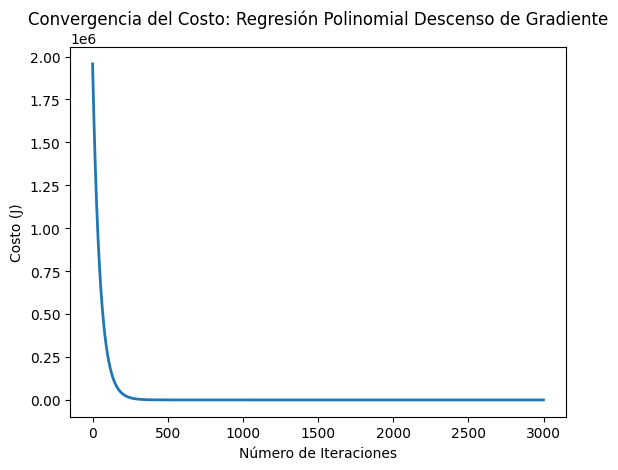

Theta Optimo tras Entrenamiento (Primeros 10 de Muestra):
[ 1.99839178e+03  1.74718808e+00 -2.94457873e+00 -1.74829251e+00
 -7.41812374e-02 -2.47771570e-01 -2.25485471e+00  5.45912430e-02
 -7.81089733e-01 -6.06224731e-01]

--- INICIO MÓDULO PREDICCTIVO EN PRUEBAS EXPERIMENTALES (TEST 20%) ---
-> Error Promedio general Absoluto (MAE): 6.69 años de margen con el Descenso.
--------------------------------------------------
Prueba Test Muestra [1]: Año Real = 1984 | Año Predicho Regresión P. = 2001.61
Prueba Test Muestra [2]: Año Real = 1996 | Año Predicho Regresión P. = 1996.43
Prueba Test Muestra [3]: Año Real = 1994 | Año Predicho Regresión P. = 1997.62
Prueba Test Muestra [4]: Año Real = 1989 | Año Predicho Regresión P. = 1994.17
Prueba Test Muestra [5]: Año Real = 2006 | Año Predicho Regresión P. = 2005.91


In [8]:

alpha = 0.01
num_iters = 3000

# Iniciamos vector inicial optimizable a ceros basándonos en variables Entrenamiento
theta = np.zeros(X_ready_train.shape[1])

theta, J_history = gradientDescentMulti(X_ready_train, y_train, theta, alpha, num_iters)

# Graficación histórico del Error
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de Iteraciones')
pyplot.ylabel('Costo (J)')
pyplot.title('Convergencia del Costo: Regresión Polinomial Descenso de Gradiente')
pyplot.show()

print('Theta Optimo tras Entrenamiento (Primeros 10 de Muestra):')
print(theta[:10])

# VALIDACIÓN Y PRUEBA DE EFECTIVIDAD EN TEST 
print("\n--- INICIO MÓDULO PREDICCTIVO EN PRUEBAS EXPERIMENTALES (TEST 20%) ---")

# Calculamos predicciones sobre nuestro subconjunto validativo de 20%
pred_y_test_descent = np.dot(X_ready_test, theta)

# Calcular Error Medio Absoluto (Mean Absolute Error, MAE) simulando efectividad base manual
mae_descent = np.mean(np.abs(pred_y_test_descent - y_test))

print(f"-> Error Promedio general Absoluto (MAE): {mae_descent:.2f} años de margen con el Descenso.")
print("-" * 50)

# Bucle visual predictivo comparativo (5 casos)
for i in range(5):
    print(f"Prueba Test Muestra [{i+1}]: Año Real = {y_test[i]} | Año Predicho Regresión P. = {pred_y_test_descent[i]:.2f}")

## Resolución mediante la Ecuación de la Normal (Normal Equation)

La computación de la Ecuación de la Normal nos da los thetas justos ($\theta$) por inversión de la matriz matemática exacta. Con esta modalidad no se requiere escalar/normalizar los números ni ejecutar un loop iterativo, la condición excluyente suele ser un límite de hardware a partir de matrices de $X$ abismalmente largas ($N\approx \ge 10000$ variables o similar número computacional). 

Fórmula:

$$ \theta = (X^T X)^{-1} X^T y $$

*(Atención: La `X` de este apartado asume valores originarios sin `featureNormalize`, el único requisito funcional es concatenar la intersección $x_0 = 1$ al tensor).*

In [9]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    
    # Ecuación Vectorizada General
    xtx = np.dot(X.T, X)
    
    # Usamos Pseudo-inversa NumPy por seguridad en caso que los Features elevados sean Singulares
    inv_xtx = np.dot(np.linalg.pinv(xtx), X.T)
    theta = np.dot(inv_xtx, y)
    
    return theta

# Usamos la Matriz Orig. de Entrenamiento (Polinómica SIN normalizar)
X_normEq_train = np.concatenate([np.ones((m_train, 1)), X_poly_train], axis=1)

# Resoluciones Theta Analítica pura 
theta_normal = normalEqn(X_normEq_train, y_train)

# Extracción de Thetas Listos, Validando Prueba (Test con Ecuación Normal) 
# Armamos la estructura de Prueba Polinómica SIN Normalizar
X_normEq_test = np.concatenate([np.ones((m_test, 1)), X_poly_test], axis=1)

pred_y_normals = np.dot(X_normEq_test, theta_normal)

# Evaluación Error Ecución Normal
mae_normal = np.mean(np.abs(pred_y_normals - y_test))

print(f"Error Promedio general Absoluto (MAE) resolviendo c/ Ec. Normal: {mae_normal:.2f} años.\n")

print("--- Comparativas de Test Aleatorias con Módulo Normal ---")
for i in range(5):
    print(f"Eq.Normal Eval [{i+1}]: Año Real = {y_test[i]} | Año Predicho Analíticamente = {pred_y_normals[i]:.2f}")

Error Promedio general Absoluto (MAE) resolviendo c/ Ec. Normal: 32.66 años.

--- Comparativas de Test Aleatorias con Módulo Normal ---
Eq.Normal Eval [1]: Año Real = 1984 | Año Predicho Analíticamente = 1989.22
Eq.Normal Eval [2]: Año Real = 1996 | Año Predicho Analíticamente = 2002.99
Eq.Normal Eval [3]: Año Real = 1994 | Año Predicho Analíticamente = 2007.21
Eq.Normal Eval [4]: Año Real = 1989 | Año Predicho Analíticamente = 1985.36
Eq.Normal Eval [5]: Año Real = 2006 | Año Predicho Analíticamente = 2067.80


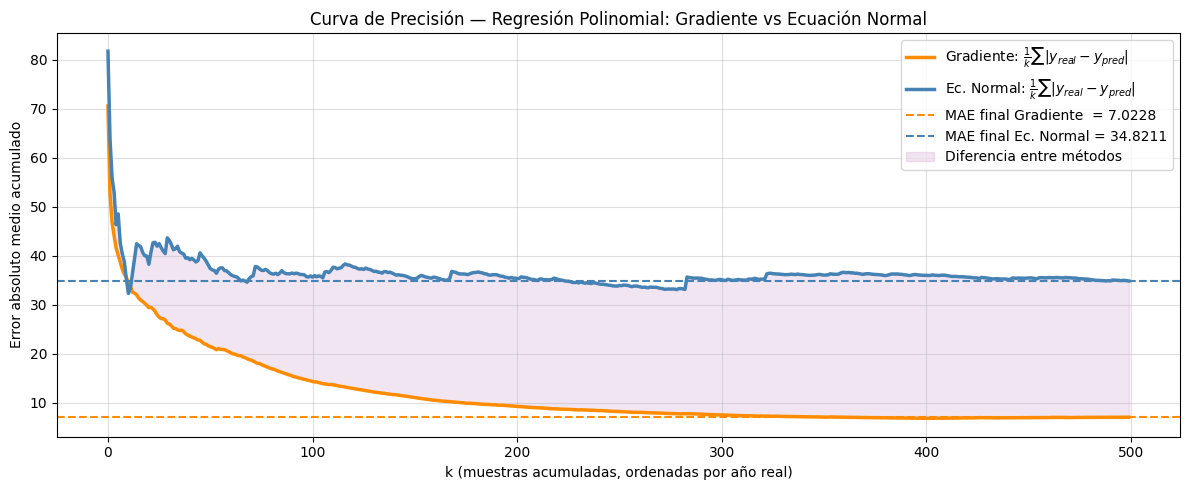

RESUMEN FINAL DE PRECISIÓN
MAE Descenso Gradiente:  7.0228
MAE Ecuación Normal:     34.8211
Método más preciso:      Gradiente


In [10]:

N = min(500, m_test)

y_real = y_test[:N]
y_pred_gd  = pred_y_test_descent[:N]   # predicciones del gradiente
y_pred_neq = pred_y_normals[:N]        # predicciones de la ecuación normal

# Ordenamos por y_real para curva progresiva
orden = np.argsort(y_real)
y_real_ord    = y_real[orden]
y_pred_gd_ord = y_pred_gd[orden]
y_pred_neq_ord = y_pred_neq[orden]

# MAE acumulativo para cada método
# Error(k) = (1/k) * Σ|y_real - y_pred|
error_gd  = np.cumsum(np.abs(y_real_ord - y_pred_gd_ord))  / np.arange(1, N+1)
error_neq = np.cumsum(np.abs(y_real_ord - y_pred_neq_ord)) / np.arange(1, N+1)

pyplot.figure(figsize=(12, 5))
pyplot.plot(np.arange(N), error_gd,  color='darkorange', lw=2.5,
            label=r'Gradiente: $\frac{1}{k}\sum|y_{real}-y_{pred}|$')
pyplot.plot(np.arange(N), error_neq, color='steelblue',  lw=2.5,
            label=r'Ec. Normal: $\frac{1}{k}\sum|y_{real}-y_{pred}|$')
pyplot.axhline(y=error_gd[-1],  color='darkorange', linestyle='--', lw=1.5,
               label=f'MAE final Gradiente  = {error_gd[-1]:.4f}')
pyplot.axhline(y=error_neq[-1], color='steelblue',  linestyle='--', lw=1.5,
               label=f'MAE final Ec. Normal = {error_neq[-1]:.4f}')
pyplot.fill_between(np.arange(N), error_gd, error_neq, alpha=0.1, color='purple',
                    label='Diferencia entre métodos')
pyplot.xlabel('k (muestras acumuladas, ordenadas por año real)')
pyplot.ylabel('Error absoluto medio acumulado')
pyplot.title('Curva de Precisión — Regresión Polinomial: Gradiente vs Ecuación Normal')
pyplot.legend()
pyplot.grid(True, alpha=0.4)
pyplot.tight_layout()
pyplot.show()

print('=' * 50)
print('RESUMEN FINAL DE PRECISIÓN')
print('=' * 50)
print(f'MAE Descenso Gradiente:  {error_gd[-1]:.4f}')
print(f'MAE Ecuación Normal:     {error_neq[-1]:.4f}')
mejor = 'Gradiente' if error_gd[-1] < error_neq[-1] else 'Ecuación Normal'
print(f'Método más preciso:      {mejor}')